# Synthetic Radar Signal Analysis

This notebook generates a synthetic radar dataset for exploring the relationship between target distance and observed signal strength.

The analysis uses a simplified signal attenuation model, introduces random measurement noise, and injects known signal anomalies for later detection and evaluation.

> **Note:** The simulated signal model is intentionally simplified for data analysis and demonstration purposes. It is not intended to represent a complete physical radar model.

## Analytical Question

**Can unusually weak radar signals be identified relative to the expected relationship between signal strength and target distance?**

Radar signal strength naturally decreases as target distance increases. As a result, a weak signal is not necessarily abnormal simply because its measured strength is low.

This analysis explores whether signal anomalies can be identified by comparing observed signal strength with the signal strength expected for a target's distance from the radar. Identifying unexpectedly weak signals can help distinguish normal distance-related attenuation from observations that may warrant further investigation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "timestamp": pd.date_range(
        start="2025-01-01",
        periods=n,
        freq="s"
    ),
    "x": np.random.normal(0, 100, n),
    "y": np.random.normal(0, 100, n),
    "z": np.random.normal(50, 20, n),
    "velocity": np.random.normal(30, 5, n)
})

data.head()

,timestamp,x,y,z,velocity
0,2025-01-01 00:00:00,49.671415,92.617755,77.987109,33.891805
1,2025-01-01 00:00:01,-13.826430,190.941664,68.492674,27.244071
2,2025-01-01 00:00:02,64.768854,-139.856757,51.192607,25.909006
3,2025-01-01 00:00:03,152.302986,56.296924,37.061264,29.983128
4,2025-01-01 00:00:04,-23.415337,-65.064257,63.964466,29.149077


## Calculate Target Distance

The radar is assumed to be located at the origin `(0, 0, 0)`.

The Euclidean distance from the radar to each target is calculated using the target's `x`, `y`, and `z` coordinates.

In [2]:
data["distance"] = np.sqrt(
    data["x"] ** 2 +
    data["y"] ** 2 +
    data["z"] ** 2
)

data.head()

,timestamp,x,y,z,velocity,distance
0,2025-01-01 00:00:00,49.671415,92.617755,77.987109,33.891805,130.871262
1,2025-01-01 00:00:01,-13.826430,190.941664,68.492674,27.244071,203.325197
2,2025-01-01 00:00:02,64.768854,-139.856757,51.192607,25.909006,162.405665
3,2025-01-01 00:00:03,152.302986,56.296924,37.061264,29.983128,166.550534
4,2025-01-01 00:00:04,-23.415337,-65.064257,63.964466,29.149077,94.197073


## Simulate Radar Signal Strength

Radar signal strength generally decreases as the distance between the radar and the target increases.

For this synthetic dataset, expected signal strength is modeled as a decreasing function of distance. Random noise is added to represent normal measurement variation.

In [3]:
expected_signal = 1 / (1 + data["distance"] / 150)

noise = np.random.normal(0, 0.03, n)

data["signal_strength"] = expected_signal + noise

data["signal_strength"] = data["signal_strength"].clip(
    lower=0,
    upper=1
)

data.head()

,timestamp,x,y,z,velocity,distance,signal_strength
0,2025-01-01 00:00:00,49.671415,92.617755,77.987109,33.891805,130.871262,0.513797
1,2025-01-01 00:00:01,-13.826430,190.941664,68.492674,27.244071,203.325197,0.420203
2,2025-01-01 00:00:02,64.768854,-139.856757,51.192607,25.909006,162.405665,0.456372
3,2025-01-01 00:00:03,152.302986,56.296924,37.061264,29.983128,166.550534,0.464619
4,2025-01-01 00:00:04,-23.415337,-65.064257,63.964466,29.149077,94.197073,0.557450


## Inject Signal Anomalies

A small number of observations are intentionally assigned unusually weak signal strength values.

These injected anomalies provide known abnormal observations that can later be compared with the results of the anomaly detection process.

In [4]:
anomaly_count = 15

anomaly_indices = np.random.choice(
    data.index,
    size=anomaly_count,
    replace=False
)

data["injected_anomaly"] = False
data.loc[anomaly_indices, "injected_anomaly"] = True

data.loc[anomaly_indices, "signal_strength"] -= np.random.uniform(
    0.15,
    0.30,
    anomaly_count
)

data["signal_strength"] = data["signal_strength"].clip(
    lower=0,
    upper=1
)

data.loc[data["injected_anomaly"]].head()

,timestamp,x,y,z,velocity,distance,signal_strength,injected_anomaly
33,2025-01-01 00:00:33,-105.771093,-121.101620,62.943919,29.261987,172.670389,0.216141,True
52,2025-01-01 00:00:52,-67.692200,116.778206,59.880604,25.610087,147.665399,0.324793,True
104,2025-01-01 00:01:44,-16.128571,41.343490,72.163656,27.586282,84.717225,0.408477,True
147,2025-01-01 00:02:27,-132.045661,-5.429487,21.198982,34.928650,133.846677,0.322023,True
196,2025-01-01 00:03:16,-88.385744,32.613302,49.607244,24.998343,106.473216,0.398695,True


## Visualize Radar Target Positions

The three-dimensional scatter plot shows the spatial distribution of the simulated radar targets.

Point color represents observed signal strength, providing a visual indication of how signal strength varies across the target positions.

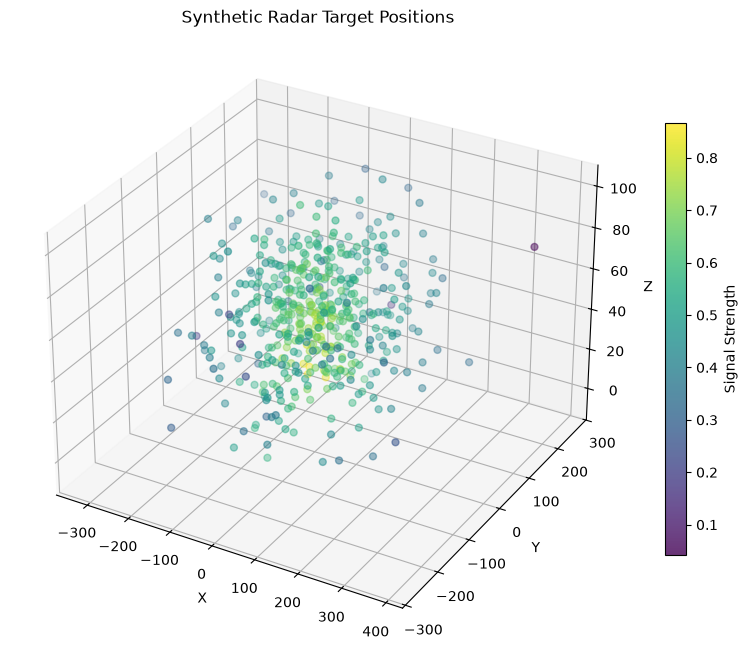

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    data["x"],
    data["y"],
    data["z"],
    c=data["signal_strength"],
    s=25,
    alpha=0.8
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Synthetic Radar Target Positions")

fig.colorbar(
    scatter,
    ax=ax,
    label="Signal Strength",
    shrink=0.7
)

plt.show()

## Examine Signal Strength by Distance

Because expected signal strength decreases with distance, a fixed signal-strength threshold is not appropriate for identifying anomalies.

Instead, observed signal strength is compared with the expected signal strength for each target's distance.

In [6]:
data["expected_signal"] = 1 / (1 + data["distance"] / 150)

data["signal_residual"] = (
    data["signal_strength"] - data["expected_signal"]
)

data[[
    "distance",
    "signal_strength",
    "expected_signal",
    "signal_residual"
]].head()

,distance,signal_strength,expected_signal,signal_residual
0,130.871262,0.513797,0.534053,-0.020255
1,203.325197,0.420203,0.424538,-0.004336
2,162.405665,0.456372,0.480145,-0.023773
3,166.550534,0.464619,0.473858,-0.009239
4,94.197073,0.557450,0.614258,-0.056808


## Detect Unusually Weak Signals

Anomalies are identified using the distribution of signal residuals.

An observation is flagged when its signal residual is more than three standard deviations below the mean residual. This identifies signals that are substantially weaker than expected for the target's distance.

In [7]:
residual_mean = data["signal_residual"].mean()
residual_std = data["signal_residual"].std()

anomaly_threshold = residual_mean - (3 * residual_std)

data["detected_anomaly"] = (
    data["signal_residual"] < anomaly_threshold
)

print(f"Residual mean: {residual_mean:.4f}")
print(f"Residual standard deviation: {residual_std:.4f}")
print(f"Anomaly threshold: {anomaly_threshold:.4f}")
print()
print(data["detected_anomaly"].value_counts())

Residual mean: -0.0068
Residual standard deviation: 0.0454
Anomaly threshold: -0.1430

detected_anomaly
False    486
True      14
Name: count, dtype: int64


## Evaluate Anomaly Detection

Because the synthetic dataset contains known injected anomalies, the detection results can be compared with the known anomaly labels.

This comparison shows how many injected anomalies were detected and whether any normal observations were incorrectly flagged.

In [8]:
comparison = pd.crosstab(
    data["injected_anomaly"],
    data["detected_anomaly"],
    rownames=["Injected Anomaly"],
    colnames=["Detected Anomaly"]
)

comparison

Detected Anomaly,False,True
Injected Anomaly,,
False,485,0
True,1,14


## Visualize Signal Anomalies

Observed signal strength is plotted against target distance.

Detected anomalies are highlighted to show signals that are substantially weaker than expected based on the target's distance.

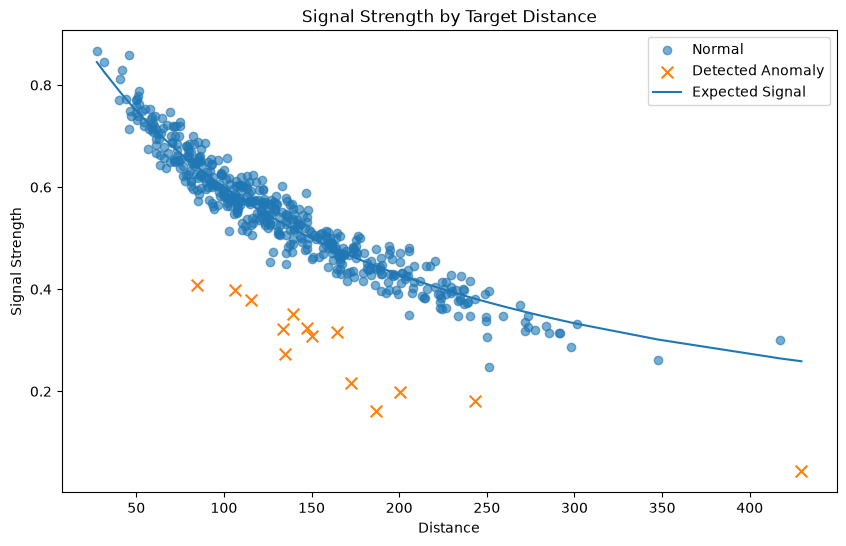

In [9]:
normal = data[~data["detected_anomaly"]]
detected = data[data["detected_anomaly"]]

plt.figure(figsize=(10, 6))

plt.scatter(
    normal["distance"],
    normal["signal_strength"],
    alpha=0.6,
    label="Normal"
)

plt.scatter(
    detected["distance"],
    detected["signal_strength"],
    s=70,
    marker="x",
    label="Detected Anomaly"
)

plt.plot(
    data["distance"].sort_values(),
    data.loc[
        data["distance"].sort_values().index,
        "expected_signal"
    ],
    label="Expected Signal"
)

plt.xlabel("Distance")
plt.ylabel("Signal Strength")
plt.title("Signal Strength by Target Distance")
plt.legend()

plt.show()

## Results and Interpretation

The anomaly detection method identified 14 of the 15 intentionally injected weak-signal observations, detecting approximately 93.3% of the known anomalies.

No normal observations were incorrectly flagged as anomalies. One injected anomaly was not detected because its signal residual did not fall below the three-standard-deviation threshold.

The signal strength visualization shows that normal observations generally follow the expected decrease in signal strength as target distance increases. Detected anomalies fall substantially below the expected signal curve.

These results demonstrate why a fixed signal-strength threshold can be misleading. A low signal strength may be normal for a distant target, while a similar signal strength may be unusually weak for a closer target. Comparing observed signal strength with the expected value for target distance provides a more meaningful basis for identifying abnormal observations.